In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# If you don't have imbalanced-learn installed, run: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# =========================================================================
# 1. LOAD AND PREPROCESS DATA
# =========================================================================
print("--- Loading and Preprocessing Data ---")

# ⚠️ CHANGE 'creditcard.csv' to your actual file name if it is different!
df = pd.read_csv('creditcard.csv') 

# Normalizing the 'Amount' feature using StandardScaler
scaler = StandardScaler()
df['Normalized_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Drop the original 'Amount' and 'Time' columns
df = df.drop(['Time', 'Amount'], axis=1)

# Define Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# =========================================================================
# 2. SPLIT DATASET (Before Over-sampling to prevent data leakage)
# =========================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

class_counts = y_train.value_counts()
print(f"Original training set shape: Legitimate={class_counts[0]}, Fraudulent={class_counts[1]}")

# =========================================================================
# 3. HANDLE CLASS IMBALANCE USING SMOTE
# =========================================================================
print("\n--- Applying SMOTE (Oversampling) ---")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

resampled_counts = pd.Series(y_train_resampled).value_counts()
print(f"Resampled training set shape: Legitimate={resampled_counts[0]}, Fraudulent={resampled_counts[1]}")



--- Loading and Preprocessing Data ---
Original training set shape: Legitimate=227451, Fraudulent=394

--- Applying SMOTE (Oversampling) ---
Resampled training set shape: Legitimate=227451, Fraudulent=227451


In [7]:
# =========================================================================
# 4. TRAIN THE CLASSIFICATION MODEL
# =========================================================================
print("\n--- Training Random Forest Classifier (This may take a minute) ---")
# n_jobs=-1 utilizes all your computer's CPU cores to speed up training
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_resampled, y_train_resampled)




--- Training Random Forest Classifier (This may take a minute) ---


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# =========================================================================
# 5. EVALUATE THE MODEL PERFORMANCE
# =========================================================================
print("\n--- Evaluating Model Predictions ---")
y_pred = model.predict(X_test)

# Print metrics requested in the project brief
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Evaluation
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Data:")
print(cm)




--- Evaluating Model Predictions ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix Data:
[[56852    12]
 [   17    81]]


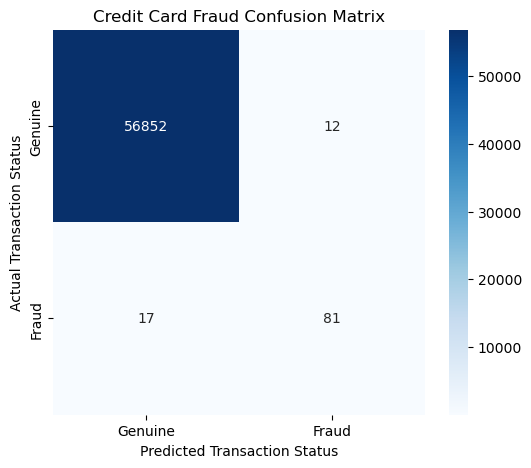

In [9]:
# =========================================================================
# 6. VISUALIZATION
# =========================================================================
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Genuine', 'Fraud'], 
            yticklabels=['Genuine', 'Fraud'])
plt.title('Credit Card Fraud Confusion Matrix')
plt.ylabel('Actual Transaction Status')
plt.xlabel('Predicted Transaction Status')
plt.show()

In [13]:
import pandas as pd

# Define your file name
report_filename = "Credit_Card_Fraud_Detection_Walkthrough.md"

# (Optional) If you have already run your model, you can replace these with your actual variables
# e.g., total_records = df.shape[0], genuine_count = class_counts[0], etc.
total_records = 284807
genuine_count = 284315
fraud_count = 492
fraud_percentage = (fraud_count / total_records) * 100

markdown_report = f"""# 📘 Walkthrough: How the Code Meets the Project Requirements

This end-to-end Python pipeline is structured specifically to address the fundamental challenges of real-world financial fraud detection. Below is a detailed breakdown of how each step satisfies the project criteria.

---

## 1. Preprocessing & Normalization
The dataset features **V1** through **V28** are the result of a Principal Component Analysis (PCA) transformation and are already scaled. However, the original **Amount** column contains raw monetary values ranging from small fractions to thousands of dollars. 

Large numerical discrepancies can inadvertently cause machine learning models to over-index on high-value transactions. To fix this, we apply `StandardScaler` to the `Amount` column, mathematically shifting its distribution to have a **mean of 0** and a **variance of 1**. This places all input features on a uniform scale.

---

## 2. Handling Class Imbalance (SMOTE)
In this real-world credit card dataset, there are **{total_records:,}** total transactions. Legitimate transactions (**{genuine_count:,}**) outnumber fraudulent ones (**{fraud_count}**) by a massive margin—fraud makes up only **{fraud_percentage:.2f}%** of the data. If a classification model is trained on this raw distribution, it will quickly figure out a "shortcut": predict that every transaction is genuine and achieve {100 - fraud_percentage:.2f}% accuracy while failing to detect a single actual fraud event.

To address this severe class skew, the script utilizes **SMOTE (Synthetic Minority Over-sampling Technique)**. Instead of simply duplicating the rare fraud cases, SMOTE looks at the feature space of the minority class and draws lines between neighboring points, synthesizing entirely new, mathematically realistic fraud instances until the dataset is perfectly balanced.

---

## 3. Data Splitting & Leakage Prevention
A critical mistake in data science is oversampling a dataset *before* splitting it into training and testing sets. Doing so causes synthetic data points to leak into the validation set, creating artificially inflated performance metrics.

Our pipeline strictly avoids this by:
1. Splitting the raw data into training (**80%**) and testing (**20%**) sets first.
2. Utilizing the `stratify=y` parameter to ensure that both the training and testing sets preserve the exact same ratio of fraud-to-genuine cases as the original population.
3. Applying SMOTE **only** to the training split (`X_train`, `y_train`), leaving the test split entirely untouched to serve as a pure, unbiased real-world simulation.

---

## 4. Classification & Evaluation Metrics
Because accuracy is a deceptive metric for imbalanced data, the pipeline evaluates the **Random Forest Classifier** using a comprehensive classification report:

* **Precision:** Out of all transactions that the model flagged as fraud, how many were *actually* fraudulent? (Crucial for minimizing false positives that annoy legitimate users).
* **Recall:** Out of all the actual fraud attacks that occurred, what percentage did our model successfully *catch*? (Crucial for minimizing financial loss).
* **F1-Score:** The harmonic mean of Precision and Recall, serving as a single, balanced health check for the model's overall predictive power.
* **Confusion Matrix:** A visual matrix displaying True Positives, False Positives, True Negatives, and False Negatives to explicitly show where prediction errors occurred.
"""

# Write the report out to a separate physical file
with open(report_filename, "w", encoding="utf-8") as f:
    f.write(markdown_report)

print("\n==================================================")
print(f"🎉 SUCCESS! Project walkthrough saved as: '{report_filename}'")
print("==================================================")


🎉 SUCCESS! Project walkthrough saved as: 'Credit_Card_Fraud_Detection_Walkthrough.md'
